
# IFRS 9 — Clean PD Development (Leakage-Free) — Beginner Notebook
**Goal:** fix AUC=1 and KS=1 by removing target leakage (e.g., Stage 3, DPD at/after default), then rebuild a simple, explainable PIT 12M PD model.

We proceed in **small, teachable steps**:
1) Import libraries & set paths  
2) Load and peek at data  
3) Standardize column names  
4) **Remove leakage** (Stage, DPD-family, default_date, LGD/EAD, etc.)  
5) **Pre-default filtering** (drop stage3 and very high DPD snapshots)  
6) Gentle DQ and simple feature engineering  
7) Build `age_months` and split by **age cohorts** (no time leakage)  
8) Train Logistic Regression (scaled) with Platt calibration  
9) Evaluate AUC, KS, Brier + calibration plot  
10) Export scoring equation & scored outputs


## 1) Import libraries and set file paths

In [1]:

import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import roc_auc_score, brier_score_loss, roc_curve

import matplotlib.pyplot as plt
from pathlib import Path

# Your Windows paths (edit if needed)
DATA_PATH = Path(r"C:\Users\customer\Desktop\MyVideos\UDEMY LESSONS\IFRS 9 Python\DEMO END-TO-END\ifrs9_pit_pd_intro_final.csv")
ARTIFACT_DIR = Path(r"C:\Users\customer\Desktop\MyVideos\UDEMY LESSONS\IFRS 9 Python\DEMO END-TO-END")

# Fallback for this environment
if not DATA_PATH.exists():
    DATA_PATH = Path("/mnt/data/ifrs9_pit_pd_intro_final.csv")
    ARTIFACT_DIR = Path("/mnt/data/IFRS9_PD_Clean")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

print("Dataset:", DATA_PATH)
print("Outputs:", ARTIFACT_DIR)


Dataset: C:\Users\customer\Desktop\MyVideos\UDEMY LESSONS\IFRS 9 Python\DEMO END-TO-END\ifrs9_pit_pd_intro_final.csv
Outputs: C:\Users\customer\Desktop\MyVideos\UDEMY LESSONS\IFRS 9 Python\DEMO END-TO-END


## 2) Load data and peek

In [3]:

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head(5)


Shape: (5000, 20)


,loan_origination_date,report_date,default_date,loan_age_m,credit_utilization,dpd,internal_score,age,macro_gdp_growth,macro_unemployment,macro_interest_rate,LGD,EAD,default_flag,account_id,employment_status,marital_status,dependents,region,stage
0,10/25/2021,3/1/2024,NaN,29,0.42,99,551,36,4.33,4.51,3.36,0.405836,59524.80636,0,9449975,Employed,Single,3,West,3
1,6/11/2018,5/1/2022,8/10/2022,47,1.00,139,868,66,0.29,6.18,2.36,0.693087,145931.71780,1,6228566,Employed,Married,0,West,3
2,2/20/2021,8/1/2024,NaN,42,0.43,27,351,57,2.29,4.14,3.41,0.418884,33587.13655,0,3844180,Employed,Divorced,0,South,2
3,12/22/2017,9/1/2024,NaN,81,1.00,154,755,21,2.50,6.88,3.23,0.700000,148398.19620,0,6931161,Employed,Married,3,South,3
4,12/4/2021,7/1/2022,10/25/2022,7,0.73,119,802,38,3.31,4.32,2.90,0.539792,129156.58160,1,2655016,Employed,Married,2,West,3


## 3) Standardize column names

In [7]:

df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]
df.columns.tolist()[:30]


['loan_origination_date',
 'report_date',
 'default_date',
 'loan_age_m',
 'credit_utilization',
 'dpd',
 'internal_score',
 'age',
 'macro_gdp_growth',
 'macro_unemployment',
 'macro_interest_rate',
 'lgd',
 'ead',
 'default_flag',
 'account_id',
 'employment_status',
 'marital_status',
 'dependents',
 'region',
 'stage']


## 4) Remove target-leaking columns

We drop variables that directly or indirectly encode the outcome:
- `stage` (Stage 3 ≈ default)
- `dpd`, `dpd_*` (contemporaneous delinquency at/after default)
- `default_date` (exists only when default happened)
- LGD/EAD behaviour variables (`lgd`, `ead`)
- common post-default artefacts: columns containing `arrears`, `chargeoff`, `collection`, `writeoff`, `status`


In [9]:

leakers = set()

# Exact-name leakers
for col in ["stage", "dpd", "dpd_clip", "dpd_30plus", "default_date", "lgd", "ead"]:
    if col in df.columns:
        leakers.add(col)

# Pattern-based leakers
for c in df.columns:
    low = c.lower()
    if any(x in low for x in ["arrears", "chargeoff", "collection", "writeoff", "status"]):
        leakers.add(c)

print("Dropping leakers:", sorted(leakers))
# Keep a copy of DPD and STAGE for optional filtering before drop
dpd_exists = "dpd" in df.columns
stage_exists = "stage" in df.columns

# We'll drop after we do the pre-default filter in the next step.


Dropping leakers: ['default_date', 'dpd', 'ead', 'employment_status', 'lgd', 'marital_status', 'stage']



## 5) Pre-default filtering (drop post-default snapshots)

To reduce leakage from **post-default behaviour**, we filter snapshots that are clearly at/after default:
- If `stage` exists, drop rows where `stage == 3`
- If `dpd` exists, drop rows where `dpd >= 60`
Then drop the leaker columns entirely.


In [11]:

initial_n = len(df)

if stage_exists:
    df = df[df["stage"] != 3].copy()

if dpd_exists:
    df = df[df["dpd"].fillna(0) < 60].copy()

filtered_n = len(df)
print(f"Rows removed by pre-default filter: {initial_n - filtered_n}")

# Now drop the leakers
df = df.drop(columns=list(leakers), errors="ignore").copy()
print("Columns after dropping leakers:", len(df.columns))


Rows removed by pre-default filter: 2677
Columns after dropping leakers: 13



## 6) Gentle data quality and simple feature engineering

- Target: `default_flag` (0/1)  
- Impute numeric columns with median; add `_miss` flags when imputing  
- Create features:
  - `score_rev` from `internal_score`
  - `util_log` from `credit_utilization` or `utilization`
  - macro variables (if present)


In [13]:

TARGET = "default_flag"
if TARGET not in df.columns:
    raise ValueError("Target 'default_flag' not found.")

# Clean target
df[TARGET] = df[TARGET].astype(float).round().clip(0,1).astype(int)

# Basic DQ: remove rows with missing target
df = df[~df[TARGET].isna()].copy()

# Impute + flags
for col in df.columns:
    if col == TARGET: 
        continue
    if pd.api.types.is_numeric_dtype(df[col]):
        miss = df[col].isna()
        if miss.any():
            df[f"{col}_miss"] = miss.astype(int)
            df[col] = df[col].fillna(df[col].median())
    else:
        miss = df[col].isna()
        if miss.any():
            df[f"{col}_miss"] = miss.astype(int)
            df[col] = df[col].fillna("UNK")

# Feature engineering
if "internal_score" in df.columns and "score_rev" not in df.columns:
    df["score_rev"] = df["internal_score"]

base_util = None
for c in ["credit_utilization", "utilization"]:
    if c in df.columns:
        base_util = c; break
if base_util and "util_log" not in df.columns:
    df["util_log"] = np.log1p(np.clip(df[base_util], 0, 1000))

print("Rows after DQ:", len(df))


Rows after DQ: 2323



## 7) Build `age_months` and split by **age cohorts**

- Train: `age_months` ≤ 6  
- Valid: 6 < `age_months` ≤ 24  
- Test:  `age_months` > 24  
If any split is empty, fall back to age quantiles (33/66/100%).


In [15]:

# Build age_months
age_candidates = ["loan_age_m","loan_age","mob","months_on_book","months_since_open","age_months","age_m","tenure_m","vintage_m"]
age_col = None
for c in age_candidates:
    if c in df.columns and pd.api.types.is_numeric_dtype(df[c]):
        age_col = c; break

if age_col is None and "loan_origination_date" in df.columns and "report_date" in df.columns:
    o = pd.to_datetime(df["loan_origination_date"], errors="coerce", infer_datetime_format=True)
    r = pd.to_datetime(df["report_date"], errors="coerce", infer_datetime_format=True)
    df["age_months"] = ((r.dt.year - o.dt.year) * 12 + (r.dt.month - o.dt.month)).astype(float)
    age_col = "age_months"

if age_col is None and "age" in df.columns and pd.api.types.is_numeric_dtype(df["age"]):
    df["age_months"] = (df["age"] * 12).astype(float)
    age_col = "age_months"

if age_col is None:
    raise ValueError("No usable age indicator found. Add a months-on-book column or date columns.")

if age_col != "age_months":
    df["age_months"] = df[age_col].astype(float)

# Quadratic + dummies
if "age2" not in df.columns:
    df["age2"] = np.square(df["age_months"])
df["age_6m"]   = (df["age_months"] <= 6).astype(int)
df["age_6_24"] = ((df["age_months"] > 6) & (df["age_months"] <= 24)).astype(int)
df["age_24p"]  = (df["age_months"] > 24).astype(int)

# Cohort split
train = df[df["age_months"] <= 6].copy()
valid = df[(df["age_months"] > 6) & (df["age_months"] <= 24)].copy()
test  = df[df["age_months"] > 24].copy()

if min(len(train), len(valid), len(test)) == 0:
    q1, q2 = df["age_months"].quantile([0.33, 0.66])
    train = df[df["age_months"] <= q1].copy()
    valid = df[(df["age_months"] > q1) & (df["age_months"] <= q2)].copy()
    test  = df[df["age_months"] > q2].copy()

print("Split sizes:", len(train), len(valid), len(test))


Split sizes: 768 777 778



## 8) Select simple features and train Logistic Regression (scaled) with calibration


In [17]:

candidate_features = [
    "score_rev", "util_log",
    "age2", "age_6m", "age_6_24", "age_24p",
    "macro_gdp_growth", "macro_unemployment", "macro_interest_rate"
]

features = [c for c in candidate_features if c in df.columns and pd.api.types.is_numeric_dtype(df[c])]
features += [c for c in df.columns if c.endswith("_miss") and pd.api.types.is_numeric_dtype(df[c])]

X_tr = train.loc[:, [c for c in features if c in train.columns]]
y_tr = train[TARGET]
X_va = valid.loc[:, [c for c in features if c in valid.columns]]
y_va = valid[TARGET]
X_te = test.loc[:,  [c for c in features if c in test.columns]]
y_te = test[TARGET]

print("Features used:", X_tr.columns.tolist())

base = Pipeline([("scaler", StandardScaler()),
                 ("logit", LogisticRegression(max_iter=200, solver="lbfgs", class_weight="balanced"))])
try:
    clf = CalibratedClassifierCV(estimator=base, cv=5, method="sigmoid")
except TypeError:
    clf = CalibratedClassifierCV(base_estimator=base, cv=5, method="sigmoid")
clf.fit(X_tr, y_tr)

pd_tr = clf.predict_proba(X_tr)[:, 1]
pd_va = clf.predict_proba(X_va)[:, 1]
pd_te = clf.predict_proba(X_te)[:, 1]


Features used: ['score_rev', 'util_log', 'age2', 'age_6m', 'age_6_24', 'age_24p', 'macro_gdp_growth', 'macro_unemployment', 'macro_interest_rate']


## 9) Evaluate AUC, KS, Brier + calibration curve

In [19]:

# KS helper (inline, simple)
fpr_tr, tpr_tr, _ = roc_curve(y_tr, pd_tr)
fpr_va, tpr_va, _ = roc_curve(y_va, pd_va)
fpr_te, tpr_te, _ = roc_curve(y_te, pd_te)
ks_tr = float(np.max(np.abs(tpr_tr - fpr_tr)))
ks_va = float(np.max(np.abs(tpr_va - fpr_va)))
ks_te = float(np.max(np.abs(tpr_te - fpr_te)))

metrics = {
    "train": {"auc": roc_auc_score(y_tr, pd_tr), "ks": ks_tr, "brier": brier_score_loss(y_tr, pd_tr)},
    "valid": {"auc": roc_auc_score(y_va, pd_va), "ks": ks_va, "brier": brier_score_loss(y_va, pd_va)},
    "test":  {"auc": roc_auc_score(y_te, pd_te), "ks": ks_te, "brier": brier_score_loss(y_te, pd_te)},
}
metrics


{'train': {'auc': 0.7219587053571428,
  'ks': 0.36186974789915966,
  'brier': 0.1807032198681416},
 'valid': {'auc': 0.6702089674051656,
  'ks': 0.25853127709860063,
  'brier': 0.2872743595049808},
 'test': {'auc': 0.6069037572835041,
  'ks': 0.1667912397026321,
  'brier': 0.5755821555053637}}

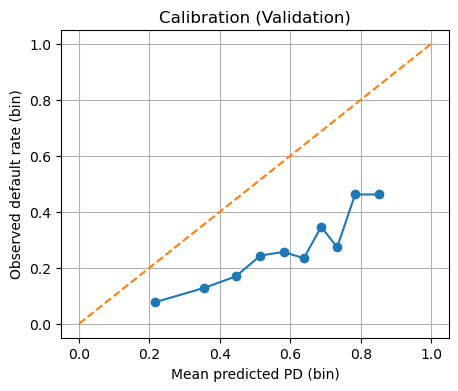

In [20]:

frac_pos, mean_pred = calibration_curve(y_va, pd_va, n_bins=10, strategy="quantile")
plt.figure(figsize=(5,4))
plt.plot(mean_pred, frac_pos, marker="o")
plt.plot([0,1],[0,1],"--")
plt.xlabel("Mean predicted PD (bin)")
plt.ylabel("Observed default rate (bin)")
plt.title("Calibration (Validation)")
plt.grid(True)
plt.show()


## 10) Scoring equation (logit) and export outputs

In [22]:

# Fit a base (uncalibrated) pipeline to extract coefficients, then convert back to original feature space
base_for_eq = Pipeline([("scaler", StandardScaler()),
                        ("logit", LogisticRegression(max_iter=200, solver="lbfgs", class_weight="balanced"))])
base_for_eq.fit(X_tr, y_tr)

scaler = base_for_eq.named_steps["scaler"]
logit  = base_for_eq.named_steps["logit"]

coef_scaled = logit.coef_.ravel()
intercept_scaled = float(logit.intercept_[0])
means = scaler.mean_
scales = scaler.scale_

beta = coef_scaled / scales
intercept = intercept_scaled - np.sum(coef_scaled * means / scales)
equation = "logit(PD_12m) = " + " ".join([f"{intercept:.6f}"] + [f"+({b:.6f}*{f})" for b, f in zip(beta, X_tr.columns)])

print(equation)

# Score splits and compute a simple ECL (illustration only)
train_out = train.copy(); train_out["pd_12m_cal"] = pd_tr
valid_out = valid.copy(); valid_out["pd_12m_cal"] = pd_va
test_out  = test.copy();  test_out["pd_12m_cal"]  = pd_te

# No LGD/EAD in features; set default placeholders for illustration
for out in [train_out, valid_out, test_out]:
    if "lgd" not in out.columns: out["lgd"] = 0.45
    if "ead" not in out.columns: out["ead"] = 1.0
    out["ecl_12m"] = out["pd_12m_cal"].clip(0,1) * out["lgd"] * out["ead"]

# Save artifacts
import json
with open(ARTIFACT_DIR / "metrics_clean.json", "w") as f:
    json.dump(metrics, f, indent=2)

pd.DataFrame({"mean_pred": mean_pred, "frac_pos": frac_pos}).to_csv(ARTIFACT_DIR / "calibration_valid_clean.csv", index=False)
train_out.to_csv(ARTIFACT_DIR / "train_scored_clean.csv", index=False)
valid_out.to_csv(ARTIFACT_DIR / "valid_scored_clean.csv", index=False)
test_out.to_csv(ARTIFACT_DIR / "test_scored_clean.csv", index=False)
with open(ARTIFACT_DIR / "scoring_equation_clean.txt", "w") as f:
    f.write(equation)

print("Saved to:", ARTIFACT_DIR)


logit(PD_12m) = -1.148960 +(-0.002745*score_rev) +(3.075219*util_log) +(0.000744*age2) +(0.000000*age_6m) +(0.434469*age_6_24) +(-0.434469*age_24p) +(0.034888*macro_gdp_growth) +(0.176969*macro_unemployment) +(-0.005375*macro_interest_rate)
Saved to: C:\Users\customer\Desktop\MyVideos\UDEMY LESSONS\IFRS 9 Python\DEMO END-TO-END
